In [2]:
import matplotlib.pyplot as plt

def plot_multi_history(histories):
    plt.figure(figsize=(12, 10))

    # -------------------
    # 1. Train Loss
    # -------------------
    plt.subplot(2, 2, 1)
    for name, history in histories.items():
        epochs = range(1, len(history["train_loss"]) + 1)
        plt.plot(epochs, history["train_loss"], label=name)
    plt.title("Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # -------------------
    # 2. Val Loss
    # -------------------
    plt.subplot(2, 2, 2)
    for name, history in histories.items():
        epochs = range(1, len(history["val_loss"]) + 1)
        plt.plot(epochs, history["val_loss"], label=name)
    plt.title("Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # -------------------
    # 3. Train Accuracy
    # -------------------
    plt.subplot(2, 2, 3)
    for name, history in histories.items():
        epochs = range(1, len(history["train_acc"]) + 1)
        plt.plot(epochs, history["train_acc"], label=name)
    plt.title("Train Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True)

    # -------------------
    # 4. Val Accuracy
    # -------------------
    plt.subplot(2, 2, 4)
    for name, history in histories.items():
        epochs = range(1, len(history["val_acc"]) + 1)
        plt.plot(epochs, history["val_acc"], label=name)
    plt.title("Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("./outputs/training_plot.png", dpi=300)
    plt.show()
    
    

In [14]:
import json

histories = dict()
with open("./outputs/cifar100_resnet50_sgd_am_history.json", "r") as f:
    data = json.load(f)
    histories["SGD Adaptive Momentum"] = data

with open("./outputs/cifar100_resnet50_fsgd_am_history.json", "r") as f:
    data = json.load(f)
    histories["Fractional SGD Adaptive Momentum"] = data

with open("./outputs/cifar100_resnet50_fsgdmr_history.json", "r") as f:
    data = json.load(f)
    histories["Fractional SGD Momentum and L2 Regularization"] = data

with open("./outputs/cifar100_resnet50_sgdm_history.json", "r") as f:
    data = json.load(f)
    histories["SGD Momentum"] = data

with open("./outputs/cifar100_resnet50_adam_history.json", "r") as f:
    data = json.load(f)
    histories["Adam"] = data

with open("./outputs/cifar10_resnet34_fosgdmr_history_0.999.json", "r") as f:
    data = json.load(f)
    histories["Adam"] = data

In [15]:
for key, value in histories.items():
    print(f"{key}: Best accuracy {max(value['val_acc'])}")

SGD Adaptive Momentum: Best accuracy 73.83
Fractional SGD Adaptive Momentum: Best accuracy 77.54
Fractional SGD Momentum and L2 Regularization: Best accuracy 73.12
SGD Momentum: Best accuracy 78.61
Adam: Best accuracy 94.54


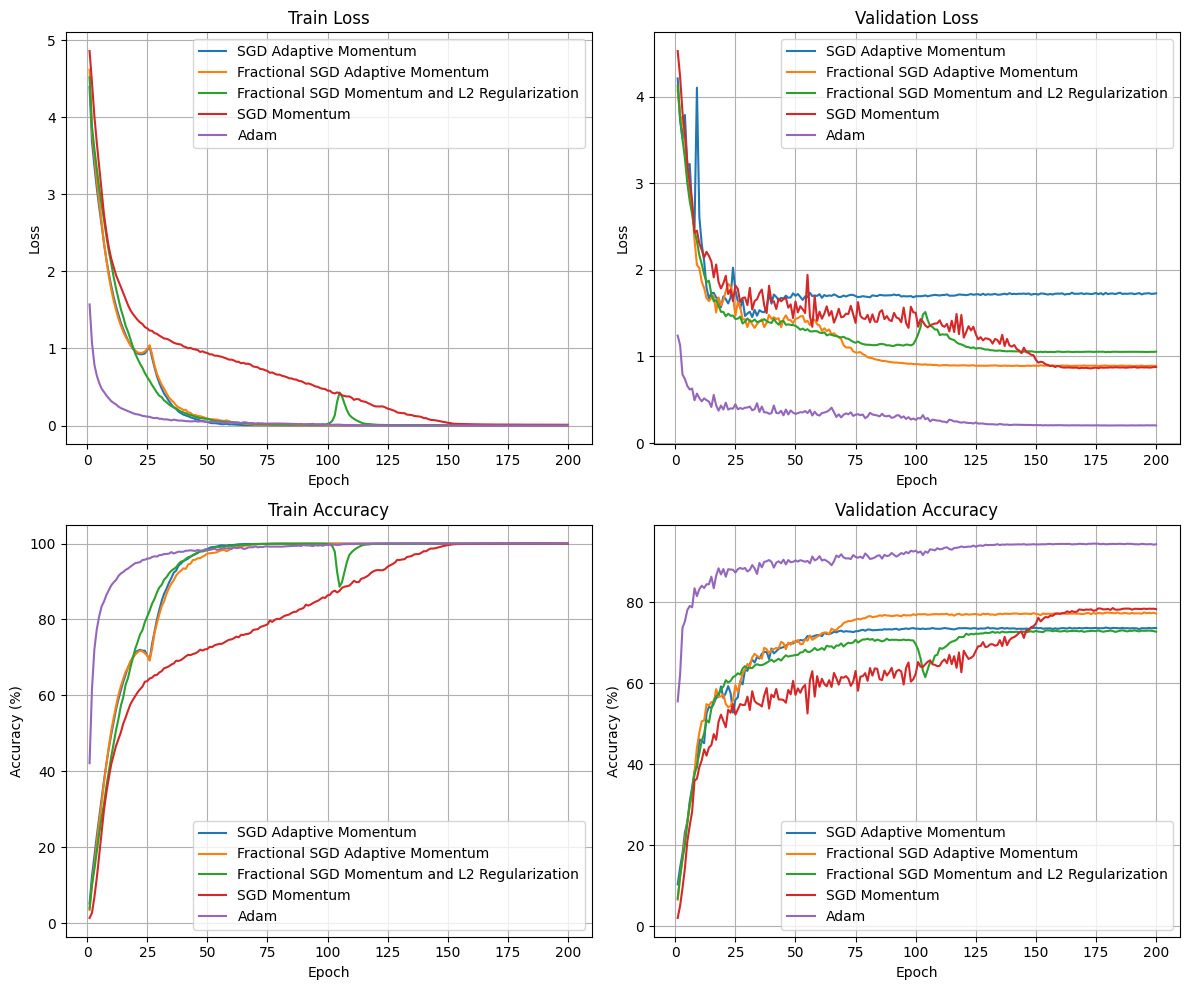

In [8]:
plot_multi_history(histories)